## Imports and Setup

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# This magic command ensures images are displayed inline in the notebook
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


## Image Loading and Rotation (Step 1)

In [ ]:
# Load the original image
# Based on your directory structure, the image is in the 'images' folder
image_path = 'images/img2.jpg'  # Changed from 'img2.jpg' to 'images/12.jpg'
img_original = cv2.imread(image_path)

if img_original is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and filename.")
else:
    # Convert BGR (OpenCV default) to RGB (for Matplotlib display later)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # --- Step 1: Create Rotated Images ---
    
    # Rotate 90 degrees Clockwise
    img_90 = cv2.rotate(img_original, cv2.ROTATE_90_CLOCKWISE)
    
    # Rotate 180 degrees
    img_180 = cv2.rotate(img_original, cv2.ROTATE_180)
    
    # Rotate 270 degrees (which is 90 degrees Counter-Clockwise)
    img_270 = cv2.rotate(img_original, cv2.ROTATE_90_COUNTERCLOCKWISE)

    print(f"Image '{image_path}' loaded and rotated successfully.")

Image 'images/12.jpg' loaded and rotated successfully.


## Defining the Matching Function (Step 2)

In [3]:
def process_and_match(img1, img2, rotation_label):
    """
    Performs SIFT feature extraction, BFMatching, Ratio Test, 
    and returns the visualization image and match count.
    """
    
    # Convert images to grayscale for feature extraction
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # --- Feature Extraction with SIFT ---
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

    # --- Matching with BFMatcher ---
    # Using k=2 for knnMatch to apply the ratio test later
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # --- Apply Ratio Test ---
    # Condition: m.distance < 0.75 * n.distance
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append([m])

    # --- Analysis Output (Step 3) ---
    print(f"Number of good matches for {rotation_label}: {len(good_matches)}")

    # Draw matches
    # drawMatchesKnn is used because 'good_matches' is a list of lists
    img_matches = cv2.drawMatchesKnn(
        img1, keypoints1,
        img2, keypoints2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    
    # Convert the final result to RGB for Matplotlib
    img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)
    
    return img_matches_rgb

## Execution and Visualization (Step 3)

Number of good matches for 90 Degree Rotation: 1527
Number of good matches for 180 Degree Rotation: 1501
Number of good matches for 270 Degree Rotation: 1542


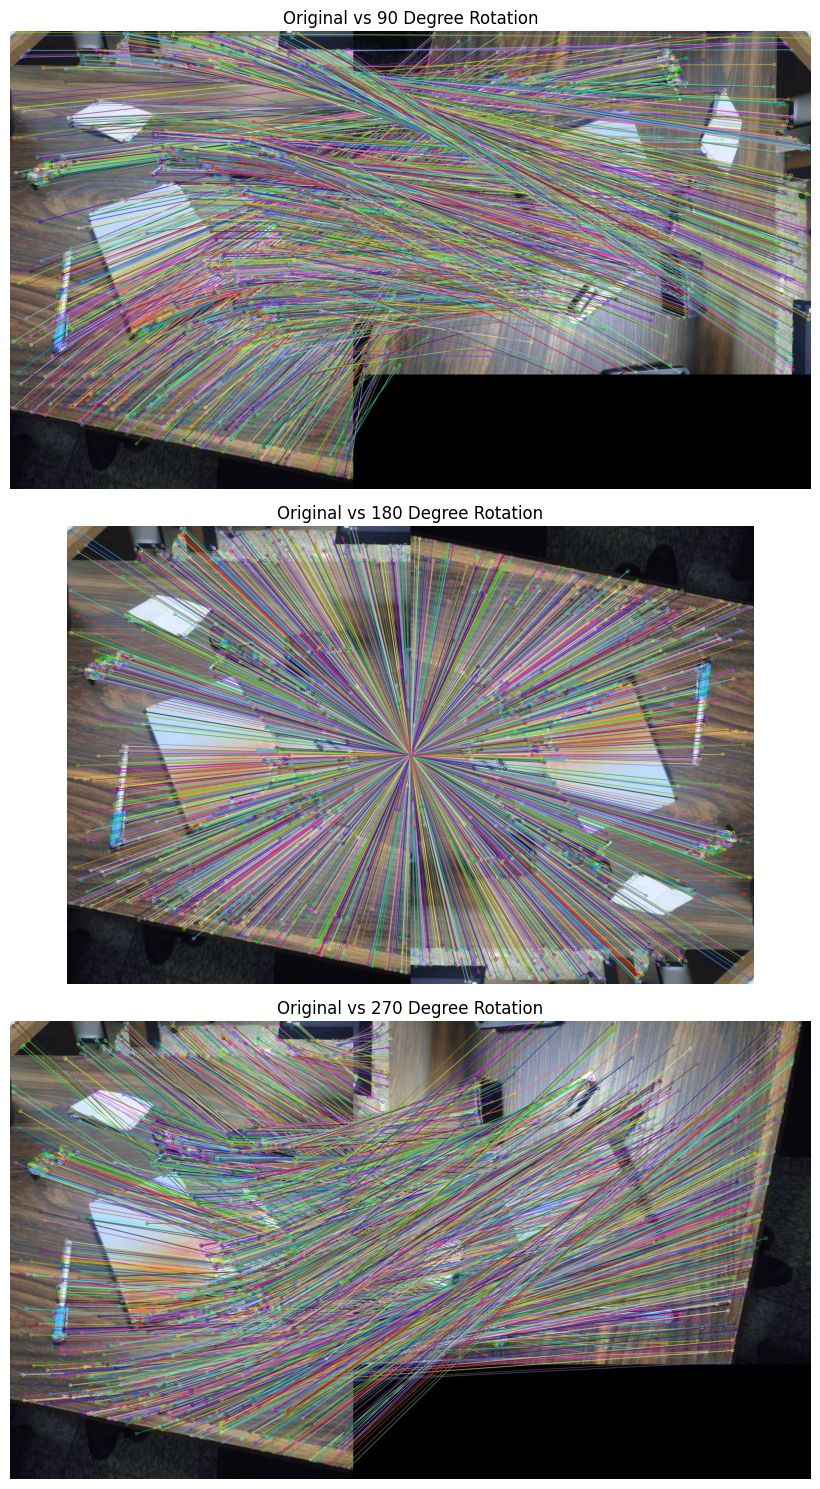

In [4]:
if img_original is not None:
    # Set up the figure for plotting
    plt.figure(figsize=(20, 15))

    # --- Case 1: Original vs 90 Degrees ---
    result_90 = process_and_match(img_original, img_90, "90 Degree Rotation")
    plt.subplot(3, 1, 1)
    plt.imshow(result_90)
    plt.title("Original vs 90 Degree Rotation")
    plt.axis('off')

    # --- Case 2: Original vs 180 Degrees ---
    result_180 = process_and_match(img_original, img_180, "180 Degree Rotation")
    plt.subplot(3, 1, 2)
    plt.imshow(result_180)
    plt.title("Original vs 180 Degree Rotation")
    plt.axis('off')

    # --- Case 3: Original vs 270 Degrees ---
    result_270 = process_and_match(img_original, img_270, "270 Degree Rotation")
    plt.subplot(3, 1, 3)
    plt.imshow(result_270)
    plt.title("Original vs 270 Degree Rotation")
    plt.axis('off')

    plt.tight_layout()
    plt.show()